<a href="https://colab.research.google.com/github/spoorthipoojary06-dotcom/Artificial-Neural-Network/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
digits=load_digits()
X = digits.data
y= digits.target

print("Shape of data:", X.shape)

print("Number of classes:", len (np.unique(y)))

Shape of data: (1797, 64)
Number of classes: 10


In [5]:
df= pd.DataFrame (X)

df['target'] = y

df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


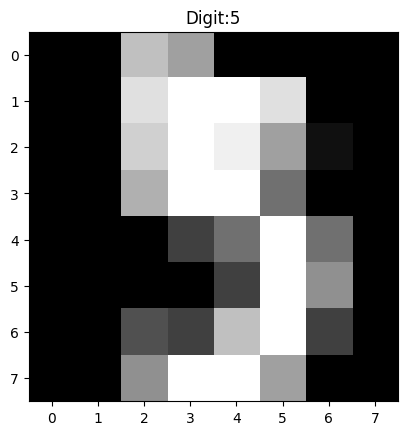

In [7]:
plt.imshow(digits.images[5], cmap='gray')
plt.title("Digit:" + str(digits.target[5]))

plt.show()

In [9]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42)


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model=MLPClassifier(hidden_layer_sizes=(100,),
max_iter=500,
random_state=42)

In [18]:
model.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [21]:
sample= X_test[10].reshape(1,-1)
prediction = model.predict(sample)
print("Predicted wine class:", prediction[0])

Predicted wine class: 1


In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9805555555555555


In [23]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average=None)
print("F1 Scores:",f1)

F1 Scores: [1.         1.         1.         0.97058824 0.98924731 0.96774194
 0.97142857 0.98507463 0.98360656 0.95      ]


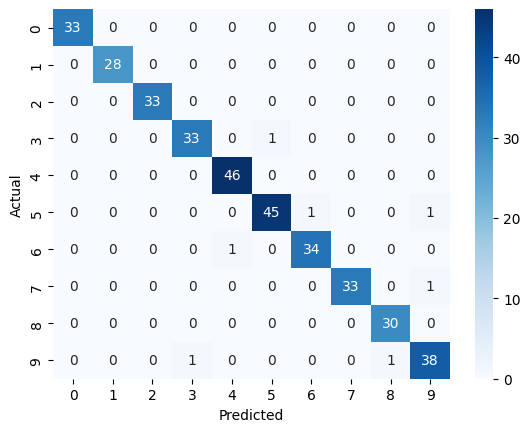

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()